# Lab: Black Box Transfer Attack

This lab demonstrates a **Black-Box Transfer Attack**. You will use a "Surrogate" model (SqueezeNet) to generate an adversarial perturbation and then test if that same perturbation can fool a "Target" model (MobileNetV2) which was never involved in the attack generation.

---

### Step 1: Environment Setup

First, we import the necessary libraries. We will use `torchvision` for pre-trained models and standard image processing.

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.datasets as datasets
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np

# Set device to CPU
device = torch.device("cpu")

---

### Step 2: Load the Models

We load **SqueezeNet 1.1** as our surrogate and **MobileNetV2** as our target. Both are pre-trained on ImageNet. To simulate a real-world attack, we treat the target model as a "black box" by only interacting with its final output.

In [2]:
# Load Surrogate Model
surrogate_model = models.squeezenet1_1(pretrained=True).to(device)
surrogate_model.eval()

# Load Target Model
target_model = models.mobilenet_v2(pretrained=True).to(device)
target_model.eval()

# Load ImageNet labels for interpretation
LABELS_URL = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
labels = requests.get(LABELS_URL).text.splitlines()

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /home/sagemaker-user/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 120MB/s]
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /home/sagemaker-user/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 185MB/s]


---

### Step 3: Image Preprocessing

Adversarial attacks are sensitive to normalization. We must ensure the input image matches the mean and standard deviation expected by ImageNet-trained models.

In [3]:
def preprocess(image_url):
    response = requests.get(image_url)
    img = Image.open(BytesIO(response.content)).convert('RGB')

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])

    # We keep the raw tensor for perturbation and normalize later
    img_tensor = transform(img).unsqueeze(0).to(device)
    return img_tensor



In [4]:
# Standard ImageNet normalization function
def normalize(tensor):
    norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    return norm(tensor)



# Experiments:

You have six sample images (Credit: Kaggle Cats vs Dogs Dataset)

- Select image index below between 0 and 5:
- `img_url = img_sources[0]`
- Run the attack
- Observe how predicted label becomes incorrect while the image is sill recognizable
- In step 5, adjust `epsilon` to increase or decrease the strength of the attack

In [17]:
# Example image: Cats and Dogs
img_sources = ["https://github.com/wsko/Statistics/raw/main/cat.12490.jpg",
               "https://github.com/wsko/Statistics/raw/main/cat.12491.jpg",
               "https://github.com/wsko/Statistics/raw/main/cat.12489.jpg",
               "https://github.com/wsko/Statistics/raw/main/dog.6.jpg",
               "https://github.com/wsko/Statistics/raw/main/dog.8.jpg",
               "https://github.com/wsko/Statistics/raw/main/dog.9.jpg"]

img_url = img_sources[0]
image_tensor = preprocess(img_url)

---

### Step 4: The Fast Gradient Sign Method (FGSM)

We will use the FGSM algorithm. It calculates the gradient of the loss with respect to the input pixels and shifts the image in the direction that increases the error.

The formula used is:


$$x_{adv} = x + \epsilon \cdot \text{sign}(\nabla_x J(\theta, x, y))$$

In [18]:
def fgsm_attack(image, epsilon, data_grad):
    # Collect the elements of the gradient sign
    sign_data_grad = data_grad.sign()
    # Create the perturbed image
    perturbed_image = image + epsilon * sign_data_grad
    # Clip to maintain [0,1] range
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    return perturbed_image

---

### Step 5: Generating the Attack (White-Box on Surrogate)

We perform the attack on SqueezeNet. We require the gradient of the input image, so we set `requires_grad = True`.

In [19]:
#Set the strength of the attack:
eps = 0.08

# epsilon too low >> no attack
# epsilon too high >> image perturbation is visible

In [20]:
# Enable gradient tracking on the input image
image_tensor.requires_grad = True

# Forward pass through Surrogate
output = surrogate_model(normalize(image_tensor))
init_pred = output.max(1, keepdim=True)[1] # Get the index of the max log-probability

# Calculate loss
loss = nn.CrossEntropyLoss()(output, init_pred[0])

# Zero all existing gradients
surrogate_model.zero_grad()

# Backward pass to get gradients
loss.backward()

# Collect gradients and generate adversarial image
data_grad = image_tensor.grad.data
epsilon = eps  # Magnitude of perturbation
adv_image = fgsm_attack(image_tensor, epsilon, data_grad)

---

### Step 6: Testing Transferability (Black-Box on Target)

Now, we take the image generated for SqueezeNet and feed it into MobileNetV2. This is the crucial "Transfer" step.

In [21]:
def get_prediction(model, tensor):
    with torch.no_grad():
        output = model(normalize(tensor))
        prob = torch.nn.functional.softmax(output[0], dim=0)
        conf, idx = torch.max(prob, 0)
    return labels[idx.item()], conf.item()

# Check Target Model on Clean Image
target_clean_label, target_clean_conf = get_prediction(target_model, image_tensor)

# Check Target Model on Adversarial Image (Transfer Attack)
target_adv_label, target_adv_conf = get_prediction(target_model, adv_image)

print(f"Target Model (Clean): {target_clean_label} ({target_clean_conf:.2%})")
print(f"Target Model (Adversarial): {target_adv_label} ({target_adv_conf:.2%})")

Target Model (Clean): Egyptian cat (40.43%)
Target Model (Adversarial): tabby (36.11%)


---

### Step 7: Visualization

Finally, we visualize the results to see if the noise is perceptible to a human.

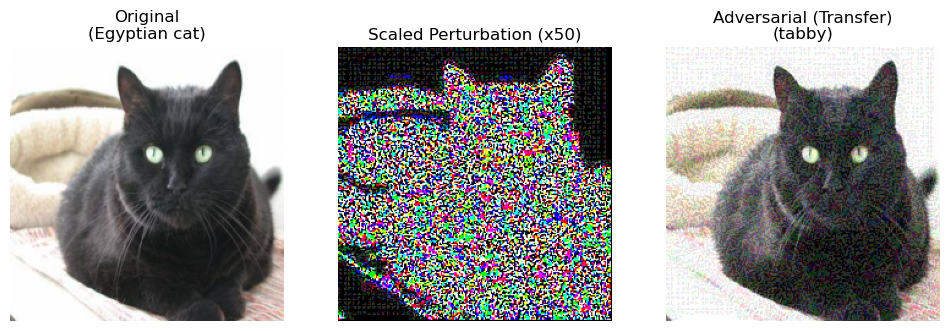

In [22]:
def imshow(img, title):
    img = img.squeeze().detach().cpu().numpy().transpose((1, 2, 0))
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
imshow(image_tensor, f"Original\n({target_clean_label})")

plt.subplot(1, 3, 2)
# Visualize the scaled perturbation (noise)
noise = (adv_image - image_tensor)
imshow(torch.clamp(noise * 50, 0, 1), "Scaled Perturbation (x50)")

plt.subplot(1, 3, 3)
imshow(adv_image, f"Adversarial (Transfer)\n({target_adv_label})")

plt.show()

### Lab Summary

* **Surrogate (SqueezeNet):** Used to compute the gradients.
* **Target (MobileNetV2):** Fooled by a perturbation it never "saw" during training or gradient calculation.
* **Key Takeaway:** Adversarial examples exploit fundamental geometric properties of the decision boundary that are often shared across different architectures.